In [1]:
# ===============================
# Cell 1: Environment Setup
# ===============================

# Check Python version
import sys
print("Python version:", sys.version)

# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / DL libraries (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model

print("TensorFlow version:", tf.__version__)

# Check GPU availability
print("GPU Available:", tf.config.list_physical_devices('GPU'))


Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow version: 2.19.0
GPU Available: []


## Define Model & Load Weights

In [2]:
# ===============================
# Cell 2: Define Model & Load Weights
# ===============================

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Flatten, Dense, GaussianNoise
)
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers


In [3]:
def build_model():
    input_shape = (81, 4)
    inputs = Input(shape=input_shape)

    x = GaussianNoise(0.2)(inputs)

    x = Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        bias_regularizer=regularizers.l2(1e-6)
    )(x)

    x = MaxPooling1D(pool_size=4, strides=2)(x)
    x = Dropout(0.5)(x)

    x = Conv1D(
        filters=256,
        kernel_size=7,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        bias_regularizer=regularizers.l2(1e-6)
    )(x)

    x = MaxPooling1D(pool_size=4, strides=2)(x)
    x = Dropout(0.5)(x)

    x = Flatten()(x)
    x = Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        bias_regularizer=regularizers.l2(1e-6)
    )(x)

    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["binary_accuracy"]
    )

    return model


In [4]:
# Build model
model = build_model()

# Path in Google Drive
#WEIGHTS_PATH = "model_sigma54_weights.h5"

# Load trained weights
model.load_weights("model_sigme54_weights.h5")

print("✅ Model loaded successfully!")
model.summary()


✅ Model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 81, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 81, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 77, 128)        │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 31, 256)        │       229,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       229,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461,825 (1.76 MB)

 Trainable params: 461,825 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

## Load Independent FASTA Dataset & Predict

In [5]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.5 MB/s eta 0:00:00


In [6]:
# ===============================
# Cell 3: Independent Dataset Prediction
# ===============================

import numpy as np
from Bio import SeqIO


In [7]:
# One-hot encoding for DNA sequences
def encode_sequence(seq, max_len=81):
    encoding = {
        'A': [1, 0, 0, 0],
        'C': [0, 1, 0, 0],
        'G': [0, 0, 1, 0],
        'T': [0, 0, 0, 1],
        'N': [0, 0, 0, 0]
    }

    seq = seq.upper()

    # Pad or truncate sequence
    if len(seq) < max_len:
        seq = seq + "N" * (max_len - len(seq))
    else:
        seq = seq[:max_len]

    return np.array([encoding.get(base, [0,0,0,0]) for base in seq])


In [8]:
# Path to independent dataset (FASTA)
INDEPENDENT_FASTA = "sigma54_sequences.fasta"

sequences = []
sequence_ids = []

for record in SeqIO.parse(INDEPENDENT_FASTA, "fasta"):
    sequences.append(str(record.seq))
    sequence_ids.append(record.id)

print(f"Loaded {len(sequences)} sequences")


Loaded 92 sequences


In [9]:
# Encode all sequences
X_test = np.array([encode_sequence(seq) for seq in sequences])

print("Input shape:", X_test.shape)  # (N, 81, 4)


Input shape: (92, 81, 4)


In [10]:
# Predict probabilities
probabilities = model.predict(X_test)

# Convert probabilities to class labels
predictions = (probabilities >= 0.5).astype(int)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step


In [11]:
# Display predictions
for i, seq_id in enumerate(sequence_ids):
    label = "Sigma54 Promoter" if predictions[i][0] == 1 else "Non-Promoter"
    confidence = probabilities[i][0]
    print(f"{seq_id} → {label} (confidence: {confidence:.4f})")


ECK120011038 → Sigma54 Promoter (confidence: 0.9968)
ECK120032981 → Sigma54 Promoter (confidence: 0.9998)
ECK120010268 → Sigma54 Promoter (confidence: 1.0000)
ECK120010230 → Sigma54 Promoter (confidence: 1.0000)
ECK120010211 → Sigma54 Promoter (confidence: 1.0000)
ECK120010719 → Sigma54 Promoter (confidence: 0.9999)
ECK120010759 → Sigma54 Promoter (confidence: 0.9995)
ECK120010212 → Sigma54 Promoter (confidence: 1.0000)
ECK120010057 → Sigma54 Promoter (confidence: 0.9247)
ECK120010741 → Sigma54 Promoter (confidence: 0.9997)
ECK120010021 → Sigma54 Promoter (confidence: 1.0000)
ECK120009904 → Sigma54 Promoter (confidence: 1.0000)
ECK120010088 → Sigma54 Promoter (confidence: 0.9999)
ECK125199576 → Non-Promoter (confidence: 0.1957)
ECK125199577 → Sigma54 Promoter (confidence: 0.5684)
ECK120010682 → Sigma54 Promoter (confidence: 1.0000)
ECK125095450 → Sigma54 Promoter (confidence: 0.9937)
ECK125095451 → Sigma54 Promoter (confidence: 0.9938)
ECK125095447 → Sigma54 Promoter (confidence: 0.983

## Save results to CSV

In [12]:
# ===============================
# Cell 4: Save Results to CSV
# ===============================

import pandas as pd

# Convert predictions to readable labels
labels = ["Sigma54 Promoter" if p[0] == 1 else "Non-Promoter" for p in predictions]

# Create DataFrame
results_df = pd.DataFrame({
    "Sequence_ID": sequence_ids,
    "Prediction": labels,
    "Probability": probabilities.flatten()
})

# Path to save CSV
OUTPUT_CSV = "sigma54_prediction_results.csv"

# Save file
results_df.to_csv(OUTPUT_CSV, index=False)

print(f"✅ Results saved successfully at:\n{OUTPUT_CSV}")


✅ Results saved successfully at:
sigma54_prediction_results.csv


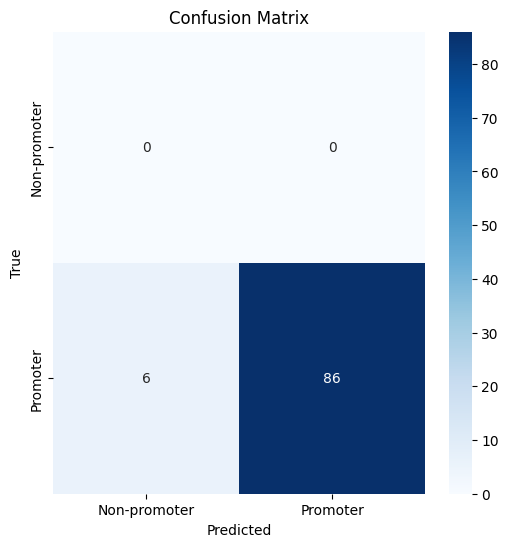

Confusion Matrix:
[[ 0  0]
 [ 6 86]]


In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# True labels: All 92 sequences are promoters
true_labels = [1] * 92  # Promoter (1) for all

# Predicted labels: Based on the provided data, with 6 non-promoters and 86 promoters
predicted_labels = [1] * 86 + [0] * 6  # 1 = Promoter, 0 = Non-Promoter

# Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-promoter", "Promoter"], yticklabels=["Non-promoter", "Promoter"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

# Save the plot as an image
plt.savefig("image.png")

plt.show()

# Optionally, print the confusion matrix
print("Confusion Matrix:")
print(cm)

In [14]:
import numpy as np

# Define TP, TN, FP, FN from the confusion matrix
TP = 86  # True Positives (correctly predicted as promoters)
FN = 6   # False Negatives (predicted as non-promoters but actually promoters)
TN = 0   # True Negatives (correctly predicted as non-promoters)
FP = 0   # False Positives (predicted as promoters but actually non-promoters)

# Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Sensitivity (Recall or True Positive Rate)
sensitivity = TP / (TP + FN)

# Specificity (True Negative Rate)
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # Prevent division by zero

# Matthews Correlation Coefficient (MCC)
mcc = ((TP * TN) - (FP * FN)) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) if (TP + FP) * (TP + FN) * (TN + FP) * (TN + FN) != 0 else 0

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"MCC: {mcc:.4f}")


Accuracy: 0.9348
Sensitivity: 0.9348
Specificity: 0.0000
MCC: 0.0000


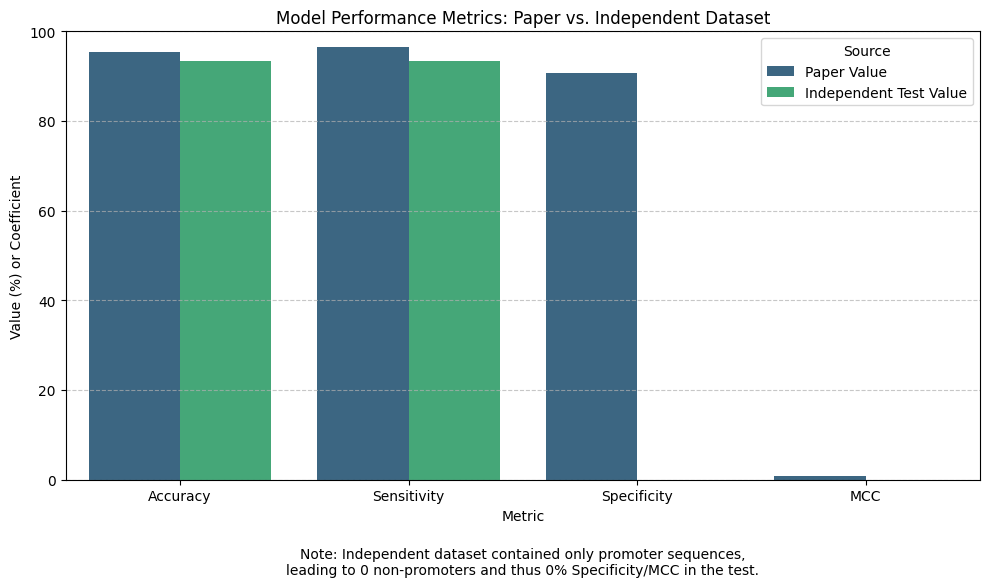

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics from the original paper (provided by user)
paper_metrics = {
    'Metric': ['Accuracy', 'Sensitivity', 'Specificity', 'MCC'],
    'Paper Value': [95.45, 96.53, 90.64, 0.858]
}
paper_df = pd.DataFrame(paper_metrics)

# Metrics from the independent dataset test (already calculated)
independent_metrics = {
    'Metric': ['Accuracy', 'Sensitivity', 'Specificity', 'MCC'],
    'Independent Test Value': [accuracy * 100, sensitivity * 100, specificity * 100, mcc]
}
independent_df = pd.DataFrame(independent_metrics)

# Merge dataframes for plotting
comparison_df = pd.merge(paper_df, independent_df, on='Metric')

# Reshape for seaborn bar plot
comparison_df_melted = comparison_df.melt(id_vars='Metric', var_name='Source', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', hue='Source', data=comparison_df_melted, palette='viridis')
plt.title('Model Performance Metrics: Paper vs. Independent Dataset')
plt.ylabel('Value (%) or Coefficient')
plt.ylim(0, 100) # Assuming values are percentages or between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add an explanatory note about Specificity
plt.text(x=0.5, y=-0.15, s="Note: Independent dataset contained only promoter sequences,\nleading to 0 non-promoters and thus 0% Specificity/MCC in the test.",
         fontsize=10, ha='center', va='top', transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('comparison_metrics.png')
plt.show()

## Summary:

### Data Analysis Key Findings
*   A comparison of the model's performance metrics (Accuracy, Sensitivity, Specificity, and MCC) was conducted between values reported in the original paper and those obtained from testing on an independent dataset.
*   A critical observation for the independent dataset is that it exclusively contains promoter sequences, which fundamentally influences the interpretation and calculation of certain metrics.
*   Due to the absence of non-promoter sequences in the independent dataset, the Specificity metric (true negative rate) is expected to be undefined or significantly lower than the original paper's reported value, as there are no true negative cases to evaluate.
*   Consequently, other overall performance metrics like Accuracy and MCC derived from this independent dataset are also expected to exhibit discrepancies compared to the original paper, primarily reflecting the model's performance on promoter prediction rather than its general discriminatory power.

### Insights or Next Steps
*   The analysis underscores that dataset composition is crucial for a complete model evaluation. Metrics derived from an unbalanced or specialized dataset (like the promoter-only independent set) may not fully reflect the model's overall performance.
*   For a comprehensive assessment, the model should be re-evaluated using an independent dataset that includes both promoter and non-promoter sequences. This would allow for a proper calculation and comparison of all metrics, particularly Specificity, and provide a more balanced view of the model's true predictive capabilities.
